In [1]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_order = pd.read_csv('../data/购买商品表.csv')
df_baby = pd.read_csv('../data/婴儿信息表.csv')
df_order.rename(columns={
    '商品详细类别ID':'二级分类',
    '商品大类ID':'一级分类',
    '商品购买数量':'购买数量',
    '商品购买日期':'购买日期',
},inplace=True)
df_order['购买日期'] = pd.to_datetime(df_order['购买日期'],format='%Y%m%d')
df_order
df_baby['出生日期'] = pd.to_datetime(df_baby['出生日期'],format='%Y%m%d')
df_baby

,用户ID,交易ID,二级分类,一级分类,商品属性,购买数量,购买日期
0,786295544,41098319944,50014866,50022520,21458:86755362;13023209:3593274;10984217:21985...,2,2014-09-19
1,532110457,17916191097,50011993,28,21458:11399317;1628862:3251296;21475:137325;16...,1,2013-10-11
2,249013725,21896936223,50012461,50014815,21458:30992;1628665:92012;1628665:3233938;1628...,1,2013-10-11
3,917056007,12515996043,50018831,50014815,21458:15841995;21956:3494076;27000458:59723383...,2,2014-10-23
4,444069173,20487688075,50013636,50008168,21458:30992;13658074:3323064;1628665:3233941;1...,1,2014-11-03
...,...,...,...,...,...,...,...
29966,57747284,35169635909,50010549,50008168,21458:125202070;22019:3228688;22019:3248884;22...,1,2014-01-09
29967,287541325,19778523000,50007011,50008168,21458:112788583;1633959:3523439;3130834:209537...,2,2014-01-09
29968,82915321,12766532512,50011993,28,21475:137325;1628665:3233937;1628665:29798;162...,1,2013-10-08
29969,78259523,18309305134,50013711,50008168,21458:30992;1628665:29778;1628665:29793;163395...,1,2013-10-08


,用户ID,出生日期,性别
0,2757,2013-03-11,1
1,415971,2012-11-11,0
2,1372572,2012-01-30,1
3,10339332,2011-09-10,0
4,10642245,2013-02-13,0
...,...,...,...
948,2020957900,2014-04-30,0
949,2080304899,2010-07-13,0
950,2114469016,2014-04-16,0
951,2186831536,2014-05-19,1


In [5]:
# 实现两个表的重复值及缺失值情况检查
# >查看两个数据表重复、缺失值情况
# 》对有缺失值的数据行进行标记
df_baby.nunique().rename('取值').to_frame().assign(
    缺失=df_baby.isna().sum(),
    总数=df_baby.shape[0],
).eval('缺失率=(缺失/总数)*100')
df_order.nunique().rename('取值').to_frame().assign(
    缺失=df_order.isna().sum(),
    总数=df_order.shape[0],
).eval('缺失率=(缺失/总数)*100')

,取值,缺失,总数,缺失率
用户ID,953,0,953,0.0
出生日期,807,0,953,0.0
性别,3,0,953,0.0


,取值,缺失,总数,缺失率
用户ID,29944,0,29971,0.000000
交易ID,28422,0,29971,0.000000
二级分类,662,0,29971,0.000000
一级分类,6,0,29971,0.000000
商品属性,28599,144,29971,0.480464
购买数量,81,0,29971,0.000000
购买日期,949,0,29971,0.000000


In [6]:
df_baby.to_csv('../data/婴儿信息表2.csv')
df_order.to_csv('../data/购买商品表2.csv')

性别
0    489
1    438
2     26
Name: count, dtype: int64

<Axes: ylabel='count'>

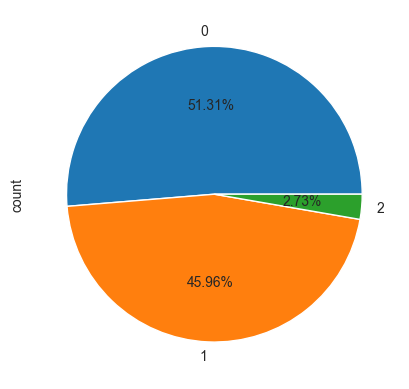

In [7]:
# 利用value_counts实现性别的分布
df1 = pd.read_csv('../data/婴儿信息表2.csv',index_col=0)
df1.性别.value_counts()
df1.性别.value_counts().plot.pie(autopct='%.2f%%')